In [138]:
# STEP 1 Analyse the data and pre-processing
import numpy as np  
import pandas as pd 
import os
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the dataset 
DATA_DIR = "C:/Users/anton/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1"
csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
print("Fichiers trouvés :", csv_files)

df_list = []

for file in csv_files:
    full_path = os.path.join(DATA_DIR, file)
    print(f"Chargement : {file}")
    df_tmp = pd.read_csv(full_path, low_memory=False)
    df_list.append(df_tmp)

for i, data in enumerate(df_list, start=1):
    rows, cols = data.shape
    print(f'df{i} -> {rows} rows, {cols} columns')
    
data = pd.concat(df_list,axis=0, ignore_index=True)

for df in df_list: del df

#Data Overview 
print(data.shape)


Fichiers trouvés : ['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']
Chargement : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Chargement : Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Chargement : Friday-WorkingHours-Morning.pcap_ISCX.csv
Chargement : Monday-WorkingHours.pcap_ISCX.csv
Chargement : Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Chargement : Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Chargement : Tuesday-WorkingHours.pcap_ISCX.csv
Chargement : Wednesday-workingHours.pcap_ISCX.csv
df1 -> 225745 rows, 79 columns
df2 -> 286467 rows, 79 columns
df3 -> 191033 rows, 79 columns
df4 -> 529918 rows, 79 column

In [139]:
# fixing columns names issues
data.columns = data.columns.str.strip()
data.sample(n=10, random_state=42)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
746827,50545,232,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
946912,53,31226,2,2,68,380,34,34,34.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2216843,80,99951883,9,7,317,11595,317,0,35.222222,105.666667,...,32,999.0,0.0,999,999,99900000.0,0.0,99900000,99900000,DoS Hulk
699389,53,30894,4,2,140,172,35,35,35.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1170268,53,48943,2,2,88,166,44,44,44.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
800686,53,23728,1,1,56,84,56,56,56.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1434488,23,3,2,0,4,0,2,2,2.000000,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1968368,80,141,2,0,0,0,0,0,0.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
934343,443,229,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
693547,443,176084,10,8,559,5437,192,0,55.900000,78.196974,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


----------
Duplicate management 
---------

In [141]:
# Checking and counting duplicates
duplicates = data.duplicated()
duplicate_count = duplicates.sum()

# Output results
print(f"Number of duplicate rows: {duplicate_count}")

# Removal of duplicates
data = data.drop_duplicates(keep='first')
del duplicates
data.shape

Number of duplicate rows: 308381


(2522362, 79)

In [142]:
#Identify columns with identical data
identical_columns = {}
columns = data.columns
list_control = columns.copy().tolist()

# Compare each pair of columns
for col1 in columns:
    for col2 in columns:
        if col1 != col2:
            if data[col1].equals(data[col2]):
                if (col1 not in identical_columns) and (col1 in list_control):
                    identical_columns[col1] = [col2]
                    list_control.remove(col2)
                elif (col1 in identical_columns) and (col1 in list_control):
                    identical_columns[col1].append(col2)
                    list_control.remove(col2)

# Print the result
if identical_columns:
    print("Identical columns found:")
    for key, value in identical_columns.items():
        print(f"'{key}' is identical to {value}")
else: print("No identical columns found.")

Identical columns found:
'Total Fwd Packets' is identical to ['Subflow Fwd Packets']
'Total Backward Packets' is identical to ['Subflow Bwd Packets']
'Fwd PSH Flags' is identical to ['SYN Flag Count']
'Bwd PSH Flags' is identical to ['Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
'Fwd URG Flags' is identical to ['CWE Flag Count']
'Fwd Header Length' is identical to ['Fwd Header Length.1']


In [143]:
# Removing the columns with duplicated values
for key, value in identical_columns.items():
    data.drop(columns=value, inplace=True)
print(data.columns)
data.shape

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count',
       'PSH Flag C

(2522362, 67)

In [144]:
# Check for numeric columns that contain only a single unique value, indicating no diversity in values.
# Such columns contribute no useful information to the analysis and may be candidates for removal.
only_unique_cols = []
for col in data.columns:
    if len(data[col].unique()) == 1:
        only_unique_cols.append(col)
        print(col)

print(f'\nThe number of columns with only one unique values is: {len(only_unique_cols)}')

# Dropping the columns with only one unique value
data.drop(only_unique_cols, axis=1, inplace=True)
del only_unique_cols

# Checking the new shape after cleaning
data.shape

Bwd PSH Flags

The number of columns with only one unique values is: 1


(2522362, 66)

--------------
Management of missing values and group maping
----------

In [146]:
 # Checking for infinite values
num_columns = data.select_dtypes(include = np.number).columns
has_infinite = np.isinf(data[num_columns]).sum()
print(has_infinite[has_infinite > 0])
# Treating infinite values
data.replace([np.inf, -np.inf], np.nan, inplace=True)

Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


In [147]:
#Dealing with Na values 
# Attack counts
attack_counts = data['Label'].value_counts().reset_index()
attack_counts.columns = ['Attack Type', 'Number of Occurrences']

# Duplicating the df and dropping rows with missing values
data_no_na = data.dropna()

# Counting the total number of occurrences of each attack after dropping
occurrences_nonull = data_no_na['Label'].value_counts().reset_index()
occurrences_nonull.columns = ['Attack Type', 'Occurrences w/o Null Rows']

# Merging the DataFrames
attack_counts = attack_counts.merge(occurrences_nonull, on='Attack Type', how='left')

# Calculating the difference
attack_counts['Abs Difference'] = attack_counts['Number of Occurrences'] - attack_counts['Occurrences w/o Null Rows']
attack_counts['Difference %'] = ((attack_counts['Abs Difference'] * 100) / attack_counts['Number of Occurrences']).round(2)

# Visualization
attack_counts

,Attack Type,Number of Occurrences,Occurrences w/o Null Rows,Abs Difference,Difference %
0,BENIGN,2096484,2095057,1427,0.07
1,DoS Hulk,172849,172846,3,0.00
2,DDoS,128016,128014,2,0.00
3,PortScan,90819,90694,125,0.14
4,DoS GoldenEye,10286,10286,0,0.00
5,FTP-Patator,5933,5931,2,0.03
6,DoS slowloris,5385,5385,0,0.00
7,DoS Slowhttptest,5228,5228,0,0.00
8,SSH-Patator,3219,3219,0,0.00
9,Bot,1953,1948,5,0.26


In [148]:
# The analysis of missing values across the dataset suggests that missing values are not heavily concentrated in any single column 
# and that the dataset can tolerate row-wise removal without significant impact.
data = data.dropna()
data.shape

(2520798, 66)

In [149]:
# Mapping the attacks to the new group
group_mapping = {
    'BENIGN': 'Normal Traffic',
    'DoS Hulk': 'DoS',
    'DDoS': 'DDoS',
    'PortScan': 'Port Scanning',
    'DoS GoldenEye': 'DoS',
    'FTP-Patator': 'Brute Force',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bots',
    'Web Attack � Brute Force': 'Web Attacks',
    'Web Attack � XSS': 'Web Attacks',
    'Infiltration': 'Infiltration',
    'Web Attack � Sql Injection': 'Web Attacks',
    'Heartbleed': 'Miscellaneous'
}

# Map to new group column
data['Attack Type'] = data['Label'].map(group_mapping)

# Checking the new values
data['Attack Type'].value_counts()

# Dropping the old 'Label' column
data.drop(columns='Label', inplace=True)

In [150]:
#Removing rows with statistically irrelevant attack types
data.drop(data[(data['Attack Type'] == 'Infiltration') | (data['Attack Type'] == 'Miscellaneous')].index, inplace=True)

In [162]:
# Data shape and attack counts after removal
print(data.shape)
data['Attack Type'].value_counts()

(2520751, 66)


Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64

-----
Correlation analysis
----

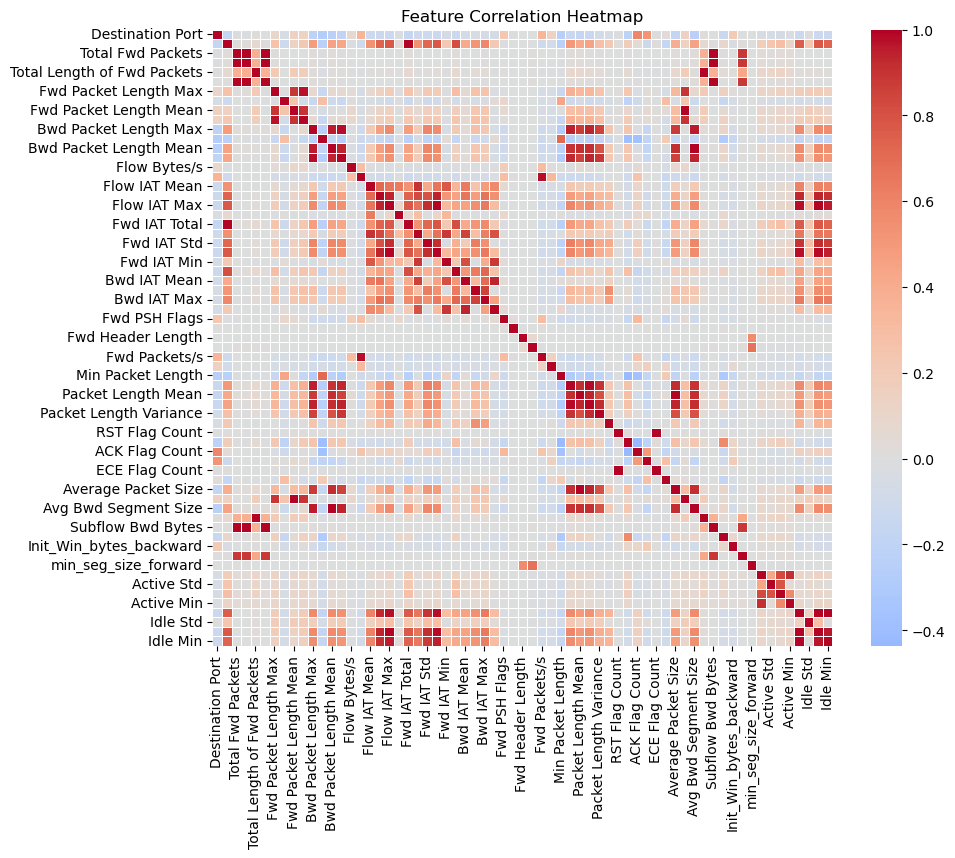

Flow Duration has a high correlation with Fwd IAT Total: 0.9985
Total Fwd Packets has a high correlation with Total Backward Packets: 0.9991
Total Fwd Packets has a high correlation with Total Length of Bwd Packets: 0.997
Total Fwd Packets has a high correlation with Subflow Bwd Bytes: 0.997
Total Backward Packets has a high correlation with Total Length of Bwd Packets: 0.9945
Total Backward Packets has a high correlation with Subflow Bwd Bytes: 0.9944
Total Length of Fwd Packets has a high correlation with Subflow Fwd Bytes: 1.0
Total Length of Bwd Packets has a high correlation with Subflow Bwd Bytes: 1.0
Fwd Packet Length Max has a high correlation with Fwd Packet Length Std: 0.9686
Fwd Packet Length Mean has a high correlation with Avg Fwd Segment Size: 1.0
Bwd Packet Length Max has a high correlation with Bwd Packet Length Mean: 0.9582
Bwd Packet Length Max has a high correlation with Bwd Packet Length Std: 0.9826
Bwd Packet Length Max has a high correlation with Avg Bwd Segment S

In [168]:
# Calculating the correlation matrix
numeric_df = data.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr(method='pearson')

plt.figure(figsize=(15, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, linewidth = 0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Identification of pairs of highly correlated features
high_corr = np.where(np.abs(correlation_matrix) >= 0.95)
high_corr = [(correlation_matrix.index[x], correlation_matrix.columns[y], correlation_matrix.iloc[x, y])
                 for x, y in zip(*high_corr) if x != y and x < y]


high_multicollinearity = []
for item in high_corr:
    print(f'{item[0]} has a high correlation with {item[1]}: {item[2].round(4)}')
    high_multicollinearity.append(item)

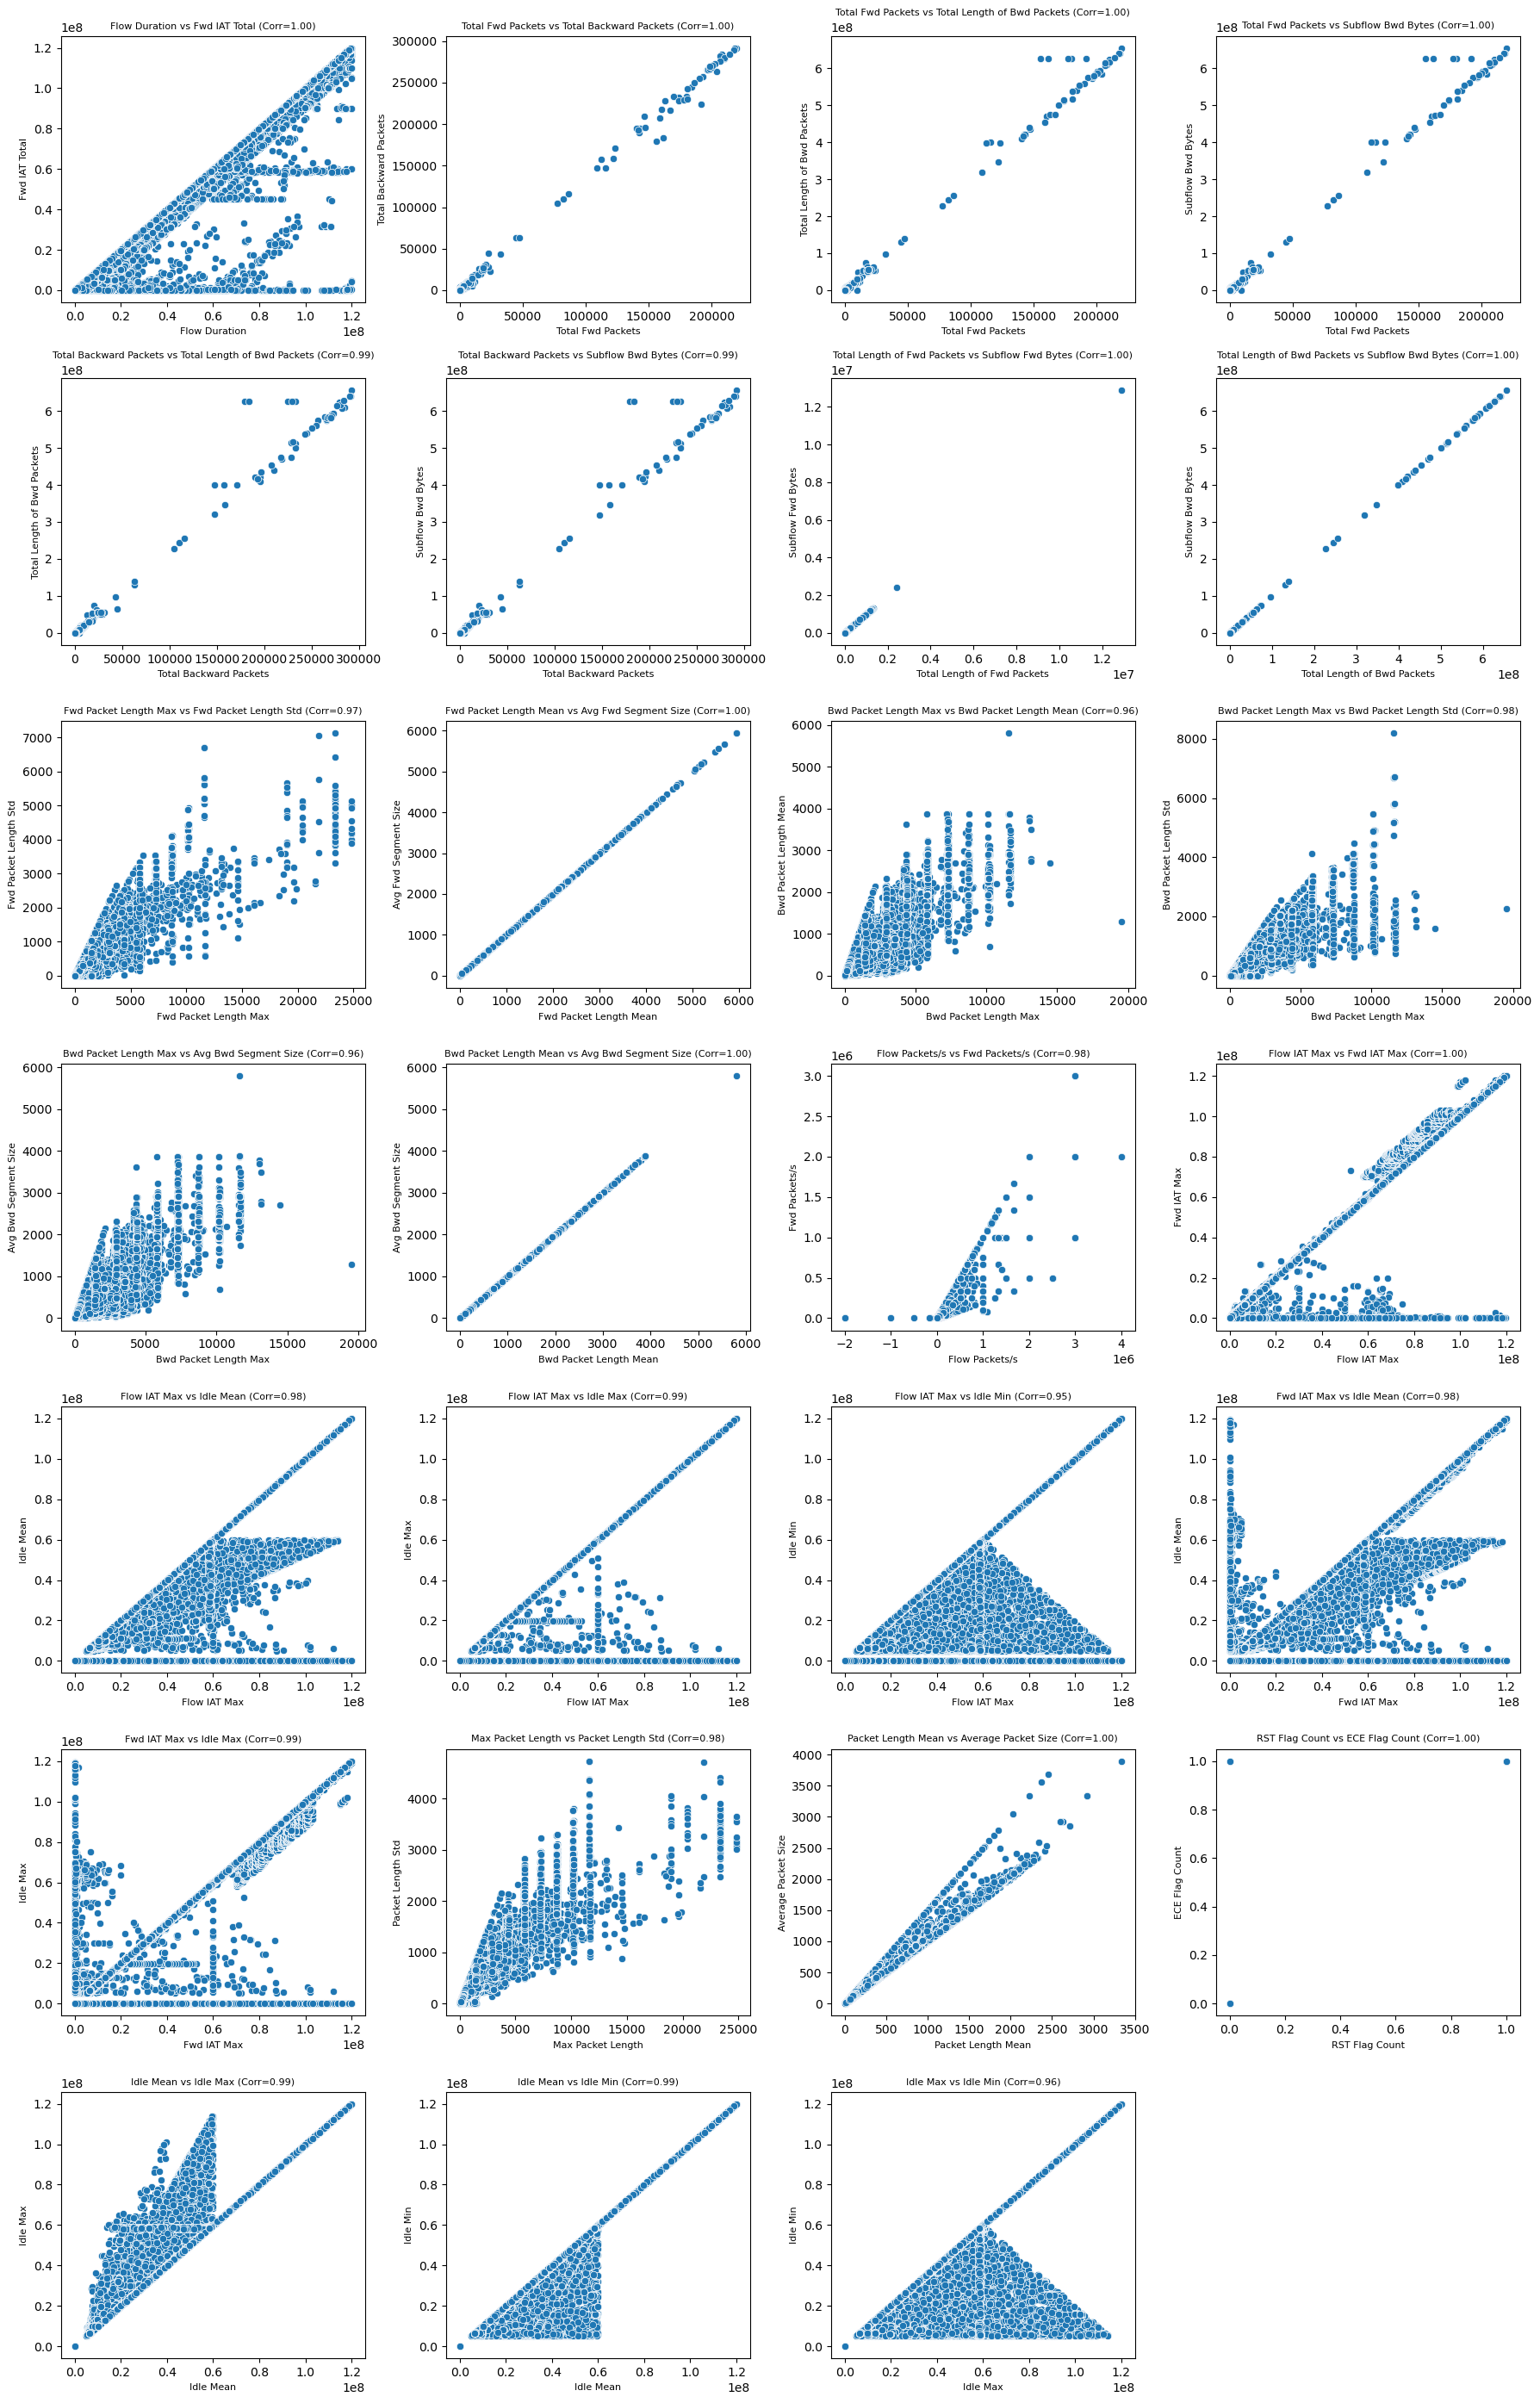

In [170]:
n_plots = len(high_multicollinearity)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, item in enumerate(high_multicollinearity):
    feature_x = item[0]
    feature_y = item[1]
    corr_value = item[2]

    # Scatter plot
    sns.scatterplot(x=data[feature_x], y=data[feature_y], ax=axes[i])
    axes[i].set_title(f'{feature_x} vs {feature_y} (Corr={corr_value:.2f})', fontsize=8)
    axes[i].set_xlabel(feature_x, fontsize=8)
    axes[i].set_ylabel(feature_y, fontsize=8)

# Hide any unused subplots
for j in range(len(high_multicollinearity), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [172]:
# We look a the plots and select the features with near perferct linear correlation
selected_columns = ['Total Backward Packets', 'Total Length of Bwd Packets', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size']
# dropping columns with perfect/near perfect multicollinearity
data.drop(columns=selected_columns, inplace=True)
data.shape

(2520751, 61)

----
Outiers Management 
---


Analyse des outliers sur 60 colonnes numériques.


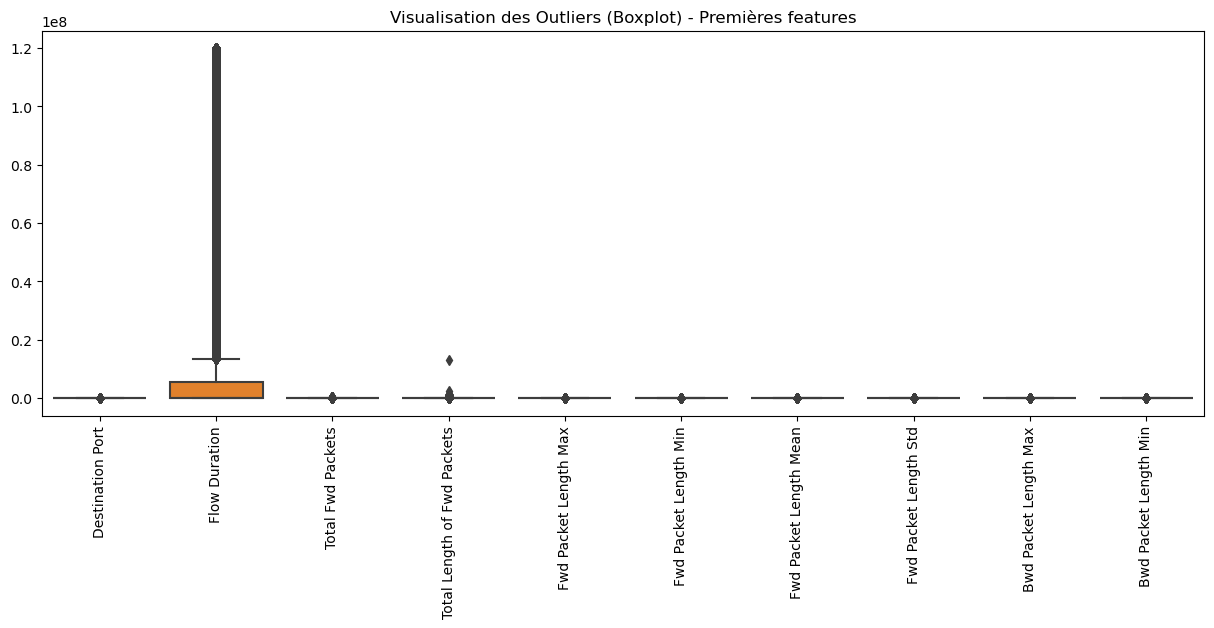

In [174]:
# On suppose que 'data' est votre DataFrame
# 1. Séparation des colonnes numériques (les outliers ne s'appliquent pas aux labels catégoriels)
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Si vous avez une colonne 'Label' ou 'Class', on l'exclut de la détection pour ne pas la modifier
if 'Attack Type' in numeric_cols:
    numeric_cols.remove('Attack Type')

print(f"Analyse des outliers sur {len(numeric_cols)} colonnes numériques.")

# --- ÉTAPE 1 : VISUALISATION (Boxplots) ---
# Le cours mentionne spécifiquement les Boxplots pour l'identification [5]
# Cela permet de voir l'étendue des outliers par variable.
plt.figure(figsize=(15, 5))
# Exemple sur les 10 premières caractéristiques pour garder le graphique lisible
sns.boxplot(data=data[numeric_cols[:10]])
plt.xticks(rotation=90)
plt.title("Visualisation des Outliers (Boxplot) - Premières features")
plt.show()

<Figure size 1500x1000 with 0 Axes>

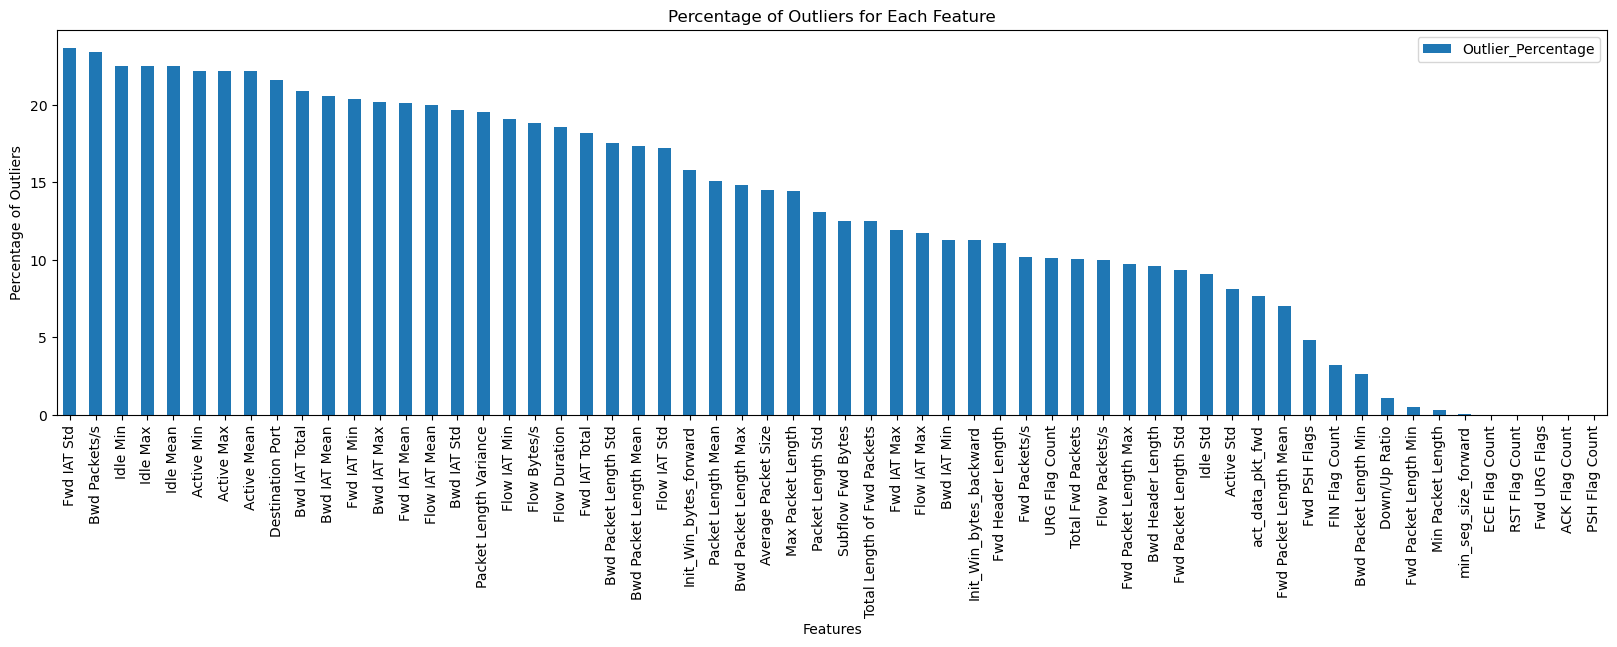

In [176]:
# --- ÉTAPE 2 : DÉTECTION STATISTIQUE (Méthode IQR) ---
# Cette méthode est robuste et standard pour définir les "moustaches" du Boxplot.

def detect_outliers_iqr(df, features):
    outlier_percentages = {}
    
    for col in features:
        # Calcul du 1er quartile (25%) et 3ème quartile (75%)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Définition des bornes (Standard : 1.5 * IQR)
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Récupération des index des outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        # Calculate the percentage of outliers for the column
        outlier_percentage = len(outliers) / len(df) * 100

        # Store the outlier percentage in the dictionary
        outlier_percentages[col] = outlier_percentage    
    
    return outlier_percentages

# Exécution de la détection
outlier_percentages  = detect_outliers_iqr(data, numeric_cols)

outliers_df = pd.DataFrame.from_dict(outlier_percentages, orient='index', columns=['Outlier_Percentage'])
# Plot the outlier percentages and highlight features above the threshold
plt.figure(figsize=(15, 10))
outliers_df.sort_values(by='Outlier_Percentage', ascending=False).plot(kind='bar', legend=False, figsize=(20, 5))
plt.xlabel('Features')
plt.ylabel('Percentage of Outliers')
plt.title('Percentage of Outliers for Each Feature')
plt.legend()
plt.show()

del outliers_df

----------
Data Distribution and class imbalance
--------


Class distribution :
Normal Traffic: 2095057 ( 83.11 %)
DoS       : 193745 (  7.69 %)
DDoS      : 128014 (  5.08 %)
Port Scanning:  90694 (  3.60 %)
Brute Force:   9150 (  0.36 %)
Web Attacks:   2143 (  0.09 %)
Bots      :   1948 (  0.08 %)


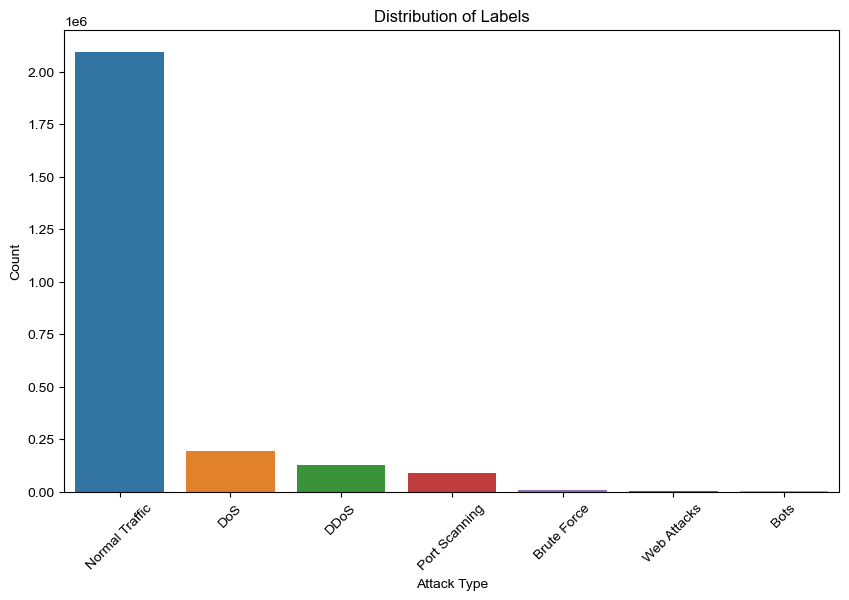


Ratio Majority/Minority : 4.92
--> Level of imbalance: weak (1:2-1:0), technique needed -> use class weight=balanced


In [178]:
df = data
# Problem formalization 
TARGET_COLUMN = 'Attack Type'
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

# analyzing imbalancing data
class_counts = y.value_counts()
total_samples = len(y)
class_percentages = (class_counts / total_samples) * 100

print("\nClass distribution :")
for attack_type, count in class_counts.items():
    percentage = class_percentages[attack_type]
    print(f'{attack_type:<10}: {count:>6} ({percentage:6.2f} %)')

plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
sns.set_theme()
plt.title('Distribution of Labels')
plt.ylabel('Count')
plt.xlabel('Attack Type')
plt.xticks(rotation=45)
plt.show()

ratio = class_counts.max() / (len(y)-class_counts.max())

print(f"\nRatio Majority/Minority : {ratio:.2f}")

if ratio >= 100:
    print("--> Level of imbalance: severe (> 100), technique needed -> hybrid sampling")
elif ratio >= 10 and ratio < 50:
    print("--> Level of imbalance: moderate (1:10-1:50 ), technique needed -> oversampling or SMOTE")
else:
    print("--> Level of imbalance: weak (1:2-1:0), technique needed -> use class weight=balanced")

In [180]:
data.to_csv('cicids2017_cleaned.csv', index=False)